# Studio sulla Normalizzazione dello Scheletro

Questo notebook presenta uno studio rigoroso sull'utilità della normalizzazione dello scheletro per l'analisi del movimento umano. La normalizzazione è una tecnica fondamentale per rendere i dati di pose invarianti rispetto a fattori estrinseci come la distanza dalla camera e le dimensioni fisiche dei soggetti.

## Obiettivi dello Studio

1. **Analizzare la variabilità** inter-soggetto dovuta a differenze antropometriche
2. **Valutare l'efficacia** della normalizzazione basata sulla distanza inter-spalla
3. **Confrontare distribuzioni** di lunghezze ossee prima e dopo la normalizzazione
4. **Quantificare** la riduzione della varianza attraverso metriche statistiche
5. **Visualizzare** gli effetti della normalizzazione su campioni reali

## 1. Setup e Import

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from sklearn.metrics import silhouette_score
import warnings
import numpy as np
from sklearn.decomposition import PCA
from umap import UMAP
from hdbscan import HDBSCAN

from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals


warnings.filterwarnings('ignore')

# Import della classe SkeletonPATS
import sys
sys.path.append('/home/paolo/Projects/Posemi/dataset/src')
from utils.skeletonPATS import SkeletonPATS

# Configurazione visualizzazioni
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Setup completato!")

/home/paolo/Projects/Posemi/dataset/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup completato!


## 2. Caricamento Dati

Carichiamo i dati di pose dal dataset processato. Ogni sample contiene sequenze temporali di keypoints 2D estratti da video di gesture.

In [8]:
# Carica tutti gli intervalli disponibili
speaker = "fallon"
split = "dev"

intervals = get_speaker_intervals(speaker, split=split)
print(f"Numero totale di dataset disponibili: {len(intervals)}")

# Per test rapido, usa un subset. Per analisi completa, usa tutti
# N_DATASETS = 20  # subset per test veloce
N_DATASETS = len(intervals)  # tutti i dataset

print(f"Useremo {N_DATASETS} dataset per l'analisi")

Numero totale di dataset disponibili: 202
Useremo 202 dataset per l'analisi


## 3. Fondamenti Teorici della Normalizzazione

### 3.1 Problema della Variabilità

I dati di pose 2D estratti da video presentano variabilità dovuta a:

1. **Distanza dalla camera**: Un soggetto più lontano produce coordinate più piccole
2. **Dimensioni antropometriche**: Persone di statura diversa hanno scheletri di dimensioni diverse
3. **Risoluzione e calibrazione**: Diversi setup di acquisizione producono scale diverse

### 3.2 Metodo di Normalizzazione

La normalizzazione basata sulla **distanza inter-spalla** è definita come:

$$
\mathbf{p}_{norm} = \frac{\mathbf{p}}{d_{shoulder}} \cdot s
$$

dove:
- $\mathbf{p}$ sono le coordinate originali
- $d_{shoulder} = ||\mathbf{p}_{LShoulder} - \mathbf{p}_{RShoulder}||_2$ è la distanza euclidea tra le spalle
- $s$ è un fattore di scala opzionale (default 1.0)

### 3.3 Vantaggi Attesi

1. **Invarianza alla scala**: Gli scheletri normalizzati hanno proporzioni confrontabili
2. **Riduzione varianza**: La variabilità inter-campione dovrebbe diminuire significativamente
3. **Migliore generalizzazione**: I modelli ML possono imparare pattern geometrici intrinseci

## 4. Analisi delle Lunghezze Ossee

Analizziamo la distribuzione delle lunghezze ossee prima e dopo la normalizzazione. Le ossa rappresentano le distanze euclidee tra joint connessi nella gerarchia scheletrica.

Calcoleremo per ogni dataset:
- **Lunghezze ossee originali**: distanze tra joint nelle coordinate pixel originali
- **Lunghezze ossee normalizzate**: dopo normalizzazione sulla distanza inter-spalla
- **Metriche statistiche**: media, deviazione standard, coefficiente di variazione (CV)

In [5]:
def compute_bone_lengths(pose: np.ndarray) -> np.ndarray:
    parents = SkeletonPATS.parents()
    T, J, _ = pose.shape
    bone_lengths = np.zeros((T, J - 1))
    
    for j, parent_idx in enumerate(parents):
        if parent_idx >= 0:
            diffs = pose[:, j, :] - pose[:, parent_idx, :]
            lengths = np.linalg.norm(diffs, axis=-1)
            bone_lengths[:, j - 1] = lengths
            
    return bone_lengths

In [9]:
from tqdm import tqdm

def compute_bone_statistics(poses: np.ndarray, normalized: bool = False, scale: float = 1.0):
    """
    Calcola statistiche sulle lunghezze ossee per un set di pose.
    
    Args:
        poses: Array di pose (T, J, 2)
        normalized: Se True, normalizza le pose prima del calcolo
        scale: Fattore di scala per la normalizzazione
    
    Returns:
        Dictionary con medie, std, CV per ogni osso
    """
    if normalized:
        poses = SkeletonPATS.normalize_skeleton(poses, scale=scale)
    
    # Calcola lunghezze ossee per ogni frame
    bone_lengths = compute_bone_lengths(poses)  # (T, J)
    
    # Calcola statistiche per ogni joint
    bone_means = np.mean(bone_lengths, axis=0)
    bone_stds = np.std(bone_lengths, axis=0)
    bone_cvs = bone_stds / (bone_means + 1e-8)  # Coefficiente di variazione
    
    return {
        'means': bone_means,
        'stds': bone_stds,
        'cvs': bone_cvs,
        'all_data': bone_lengths
    }


In [10]:
# Calcola statistiche su tutti i dataset
results = []

for idx in tqdm(range(N_DATASETS), desc="Analisi dataset"):
    try:
        # Carica dataset
        clips = load_multiple_samples(
            speaker=speaker, 
            interval_ids=intervals[idx:idx+1]
        )
        
        # Estrai pose
        skeleton_poses = []
        for clip in clips:
            pose = clip['pose']
            pose[:, 0] = [0.0, 0.0]  # centra sul collo 
            skeleton_poses.append(pose)
        
        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        
        # Salta dataset troppo piccoli
        if len(skeleton_poses) < 10:
            continue
        
        # Calcola statistiche per originali
        stats_orig = compute_bone_statistics(skeleton_poses, normalized=False)
        
        # Calcola statistiche per normalizzati
        stats_norm = compute_bone_statistics(skeleton_poses, normalized=True, scale=1.0)
        
        # Joint di interesse (spalle, gomiti, polsi)
        joints_of_interest = [1, 2, 3, 4, 5, 6]  # RShoulder, RElbow, RWrist, LShoulder, LElbow, LWrist
        
        for joint_idx in joints_of_interest:
            results.append({
                'dataset_idx': idx,
                'joint_idx': joint_idx,
                'n_frames': len(skeleton_poses),
                # Statistiche originali
                'orig_mean': stats_orig['means'][joint_idx],
                'orig_std': stats_orig['stds'][joint_idx],
                'orig_cv': stats_orig['cvs'][joint_idx],
                # Statistiche normalizzate
                'norm_mean': stats_norm['means'][joint_idx],
                'norm_std': stats_norm['stds'][joint_idx],
                'norm_cv': stats_norm['cvs'][joint_idx],
            })
    
    except Exception as e:
        print(f"Errore nel dataset {idx}: {e}")
        continue

# Converti in DataFrame
df_results = pd.DataFrame(results)
print(f"\nDataset analizzati con successo: {df_results['dataset_idx'].nunique()}")
print(f"Totale misurazioni (dataset x joint): {len(df_results)}")
print(f"\nPrime righe dei risultati:")
print(df_results.head())

Analisi dataset:  45%|████▍     | 90/202 [00:49<00:47,  2.33it/s]

Errore nel dataset 90: need at least one array to concatenate


Analisi dataset:  50%|█████     | 101/202 [00:54<00:51,  1.94it/s]

Errore nel dataset 101: need at least one array to concatenate


Analisi dataset:  57%|█████▋    | 115/202 [01:00<00:43,  1.98it/s]

Errore nel dataset 115: need at least one array to concatenate


Analisi dataset:  94%|█████████▍| 190/202 [01:41<00:08,  1.47it/s]

Errore nel dataset 190: need at least one array to concatenate


Analisi dataset: 100%|██████████| 202/202 [01:47<00:00,  1.87it/s]

Errore nel dataset 201: need at least one array to concatenate

Dataset analizzati con successo: 197
Totale misurazioni (dataset x joint): 1182

Prime righe dei risultati:
   dataset_idx  joint_idx  n_frames   orig_mean   orig_std   orig_cv  \
0            0          1       735  208.807031  19.868094  0.095151   
1            0          2       735  156.829939  48.028459  0.306245   
2            0          3       735  136.157475   8.854722  0.065033   
3            0          4       735  212.733349  12.908610  0.060680   
4            0          5       735  169.521616  43.966000  0.259353   

   norm_mean  norm_std   norm_cv  
0   0.768933  0.066639  0.086664  
1   0.576706  0.173547  0.300927  
2   0.500727  0.007935  0.015846  
3   0.785014  0.064042  0.081581  
4   0.627260  0.169258  0.269837  


## 5. Analisi delle Differenze (Paired Comparison)

Calcoliamo le differenze per ogni metrica tra originale e normalizzato:

$$\Delta_i = \text{metric}_{\text{norm}}(D_i) - \text{metric}_{\text{orig}}(D_i)$$

**Per deviazione standard e CV**: valori più bassi = meglio → $\Delta < 0$ significa normalizzazione efficace  
**Per invarianza**: $\Delta \approx 0$ significa che i rapporti anatomici sono preservati

In [22]:
# Calcola differenze per ogni metrica
# Per std e CV: valori più bassi = meglio → Delta < 0 significa normalizzazione migliore

df_results['delta_mean'] = df_results['norm_mean'] - df_results['orig_mean']
df_results['delta_std'] = df_results['norm_std'] - df_results['orig_std']
df_results['delta_cv'] = df_results['norm_cv'] - df_results['orig_cv']

# Aggiungi nomi dei joint per leggibilità
joint_names_map = {
    1: 'RShoulder',
    2: 'RElbow', 
    3: 'RWrist',
    4: 'LShoulder',
    5: 'LElbow',
    6: 'LWrist'
}
df_results['joint_name'] = df_results['joint_idx'].map(joint_names_map)

print("Statistiche descrittive delle differenze:\n")
delta_cols = [col for col in df_results.columns if col.startswith('delta_')]
print(df_results[delta_cols].describe())

print("\n\nDifferenze medie per joint:")
print(df_results.groupby('joint_name')[delta_cols].mean())

Statistiche descrittive delle differenze:

        delta_mean    delta_std     delta_cv
count  1212.000000  1212.000000  1212.000000
mean   -162.945441   -19.172037    -0.006352
std      36.398616    14.642041     0.038713
min    -311.168424   -65.042093    -0.247389
25%    -196.370840   -29.268903    -0.025349
50%    -152.872794   -13.822625    -0.003971
75%    -136.506976    -7.702938     0.008656
max     -51.281111    -0.733489     0.392154


Differenze medie per joint:
            delta_mean  delta_std  delta_cv
joint_name                                 
LElbow     -204.602295 -13.180039  0.009091
LShoulder  -138.540752  -6.927183 -0.035497
LWrist     -155.544107 -35.997212  0.016683
RElbow     -204.789593 -15.718235 -0.000557
RShoulder  -137.451832  -7.024881 -0.036566
RWrist     -136.744064 -36.184673  0.008731


## 6. Visualizzazione Confronto: Originale vs Normalizzato

Confrontiamo visivamente le distribuzioni delle metriche chiave (deviazione standard e coefficiente di variazione) prima e dopo la normalizzazione per ogni joint.

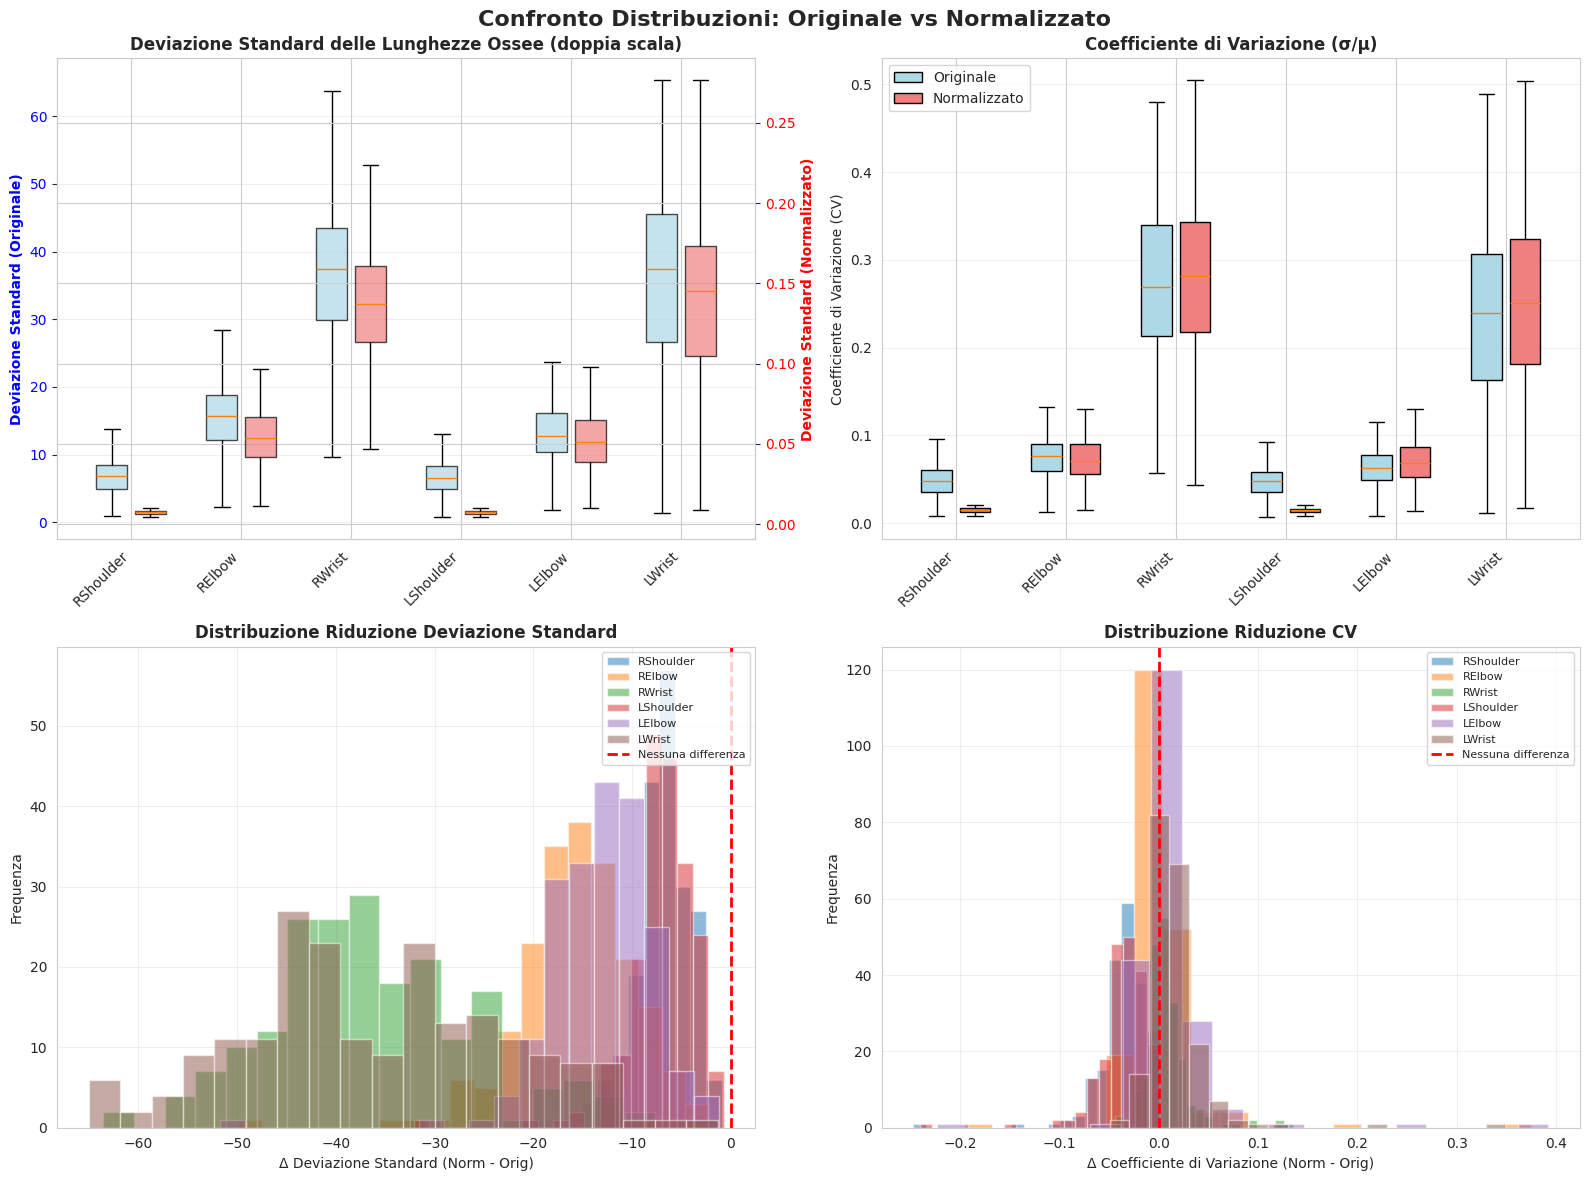


📊 STATISTICHE RIASSUNTIVE:

RShoulder:
  Δ Std medio: -7.0249 (100.0% dataset migliorati)
  Δ CV medio:  -0.0366 (100.0% dataset migliorati)

RElbow:
  Δ Std medio: -15.7182 (100.0% dataset migliorati)
  Δ CV medio:  -0.0006 (55.0% dataset migliorati)

RWrist:
  Δ Std medio: -36.1847 (100.0% dataset migliorati)
  Δ CV medio:  0.0087 (34.2% dataset migliorati)

LShoulder:
  Δ Std medio: -6.9272 (100.0% dataset migliorati)
  Δ CV medio:  -0.0355 (99.0% dataset migliorati)

LElbow:
  Δ Std medio: -13.1800 (100.0% dataset migliorati)
  Δ CV medio:  0.0091 (39.1% dataset migliorati)

LWrist:
  Δ Std medio: -35.9972 (100.0% dataset migliorati)
  Δ CV medio:  0.0167 (19.8% dataset migliorati)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confronto Distribuzioni: Originale vs Normalizzato', fontsize=16, fontweight='bold')

# 1. Deviazione Standard per Joint (con doppia scala Y)
ax = axes[0, 0]
joint_order = ['RShoulder', 'RElbow', 'RWrist', 'LShoulder', 'LElbow', 'LWrist']
positions = np.arange(len(joint_order))
width = 0.35

# Crea secondo asse y
ax2 = ax.twinx()

for i, joint in enumerate(joint_order):
    joint_data = df_results[df_results['joint_name'] == joint]
    orig_std = joint_data['orig_std'].values
    norm_std = joint_data['norm_std'].values
    
    # Plot originale sull'asse sinistro
    bp1 = ax.boxplot([orig_std], positions=[i - width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    bp1['boxes'][0].set_facecolor('lightblue')
    bp1['boxes'][0].set_alpha(0.7)
    
    # Plot normalizzato sull'asse destro
    bp2 = ax2.boxplot([norm_std], positions=[i + width/2], widths=width*0.8,
                       patch_artist=True, showfliers=False)
    bp2['boxes'][0].set_facecolor('lightcoral')
    bp2['boxes'][0].set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(joint_order, rotation=45, ha='right')
ax.set_ylabel('Deviazione Standard (Originale)', color='blue', fontweight='bold')
ax2.set_ylabel('Deviazione Standard (Normalizzato)', color='red', fontweight='bold')
ax.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax.set_title('Deviazione Standard delle Lunghezze Ossee (doppia scala)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 2. Coefficiente di Variazione per Joint
ax = axes[0, 1]
for i, joint in enumerate(joint_order):
    joint_data = df_results[df_results['joint_name'] == joint]
    orig_cv = joint_data['orig_cv'].values
    norm_cv = joint_data['norm_cv'].values
    
    bp1 = ax.boxplot([orig_cv], positions=[i - width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    bp2 = ax.boxplot([norm_cv], positions=[i + width/2], widths=width*0.8,
                      patch_artist=True, showfliers=False)
    
    bp1['boxes'][0].set_facecolor('lightblue')
    bp2['boxes'][0].set_facecolor('lightcoral')

ax.set_xticks(positions)
ax.set_xticklabels(joint_order, rotation=45, ha='right')
ax.set_ylabel('Coefficiente di Variazione (CV)')
ax.set_title('Coefficiente di Variazione (σ/μ)', fontweight='bold')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Originale', 'Normalizzato'])
ax.grid(True, alpha=0.3, axis='y')

# 3. Distribuzione Δ Std
ax = axes[1, 0]
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    ax.hist(joint_data['delta_std'], bins=20, alpha=0.5, label=joint)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
ax.set_xlabel('Δ Deviazione Standard (Norm - Orig)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Riduzione Deviazione Standard', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# 4. Distribuzione Δ CV
ax = axes[1, 1]
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    ax.hist(joint_data['delta_cv'], bins=20, alpha=0.5, label=joint)

ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
ax.set_xlabel('Δ Coefficiente di Variazione (Norm - Orig)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Riduzione CV', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa statistiche riassuntive
print("\n📊 STATISTICHE RIASSUNTIVE:")
print("="*60)
for joint in joint_order:
    joint_data = df_results[df_results['joint_name'] == joint]
    mean_delta_std = joint_data['delta_std'].mean()
    mean_delta_cv = joint_data['delta_cv'].mean()
    pct_improved_std = (joint_data['delta_std'] < 0).sum() / len(joint_data) * 100
    pct_improved_cv = (joint_data['delta_cv'] < 0).sum() / len(joint_data) * 100
    
    print(f"\n{joint}:")
    print(f"  Δ Std medio: {mean_delta_std:.4f} ({pct_improved_std:.1f}% dataset migliorati)")
    print(f"  Δ CV medio:  {mean_delta_cv:.4f} ({pct_improved_cv:.1f}% dataset migliorati)")

## 7. Visualizzazione Geometrica: Frame Singolo

Visualizziamo un frame di esempio prima e dopo la normalizzazione per comprendere l'effetto geometrico della trasformazione.

Frame selezionato: 204 del dataset 100
Distanza inter-spalla originale: 262.48 pixel
Distanza inter-spalla normalizzata: 1.00 (target = 1.0)


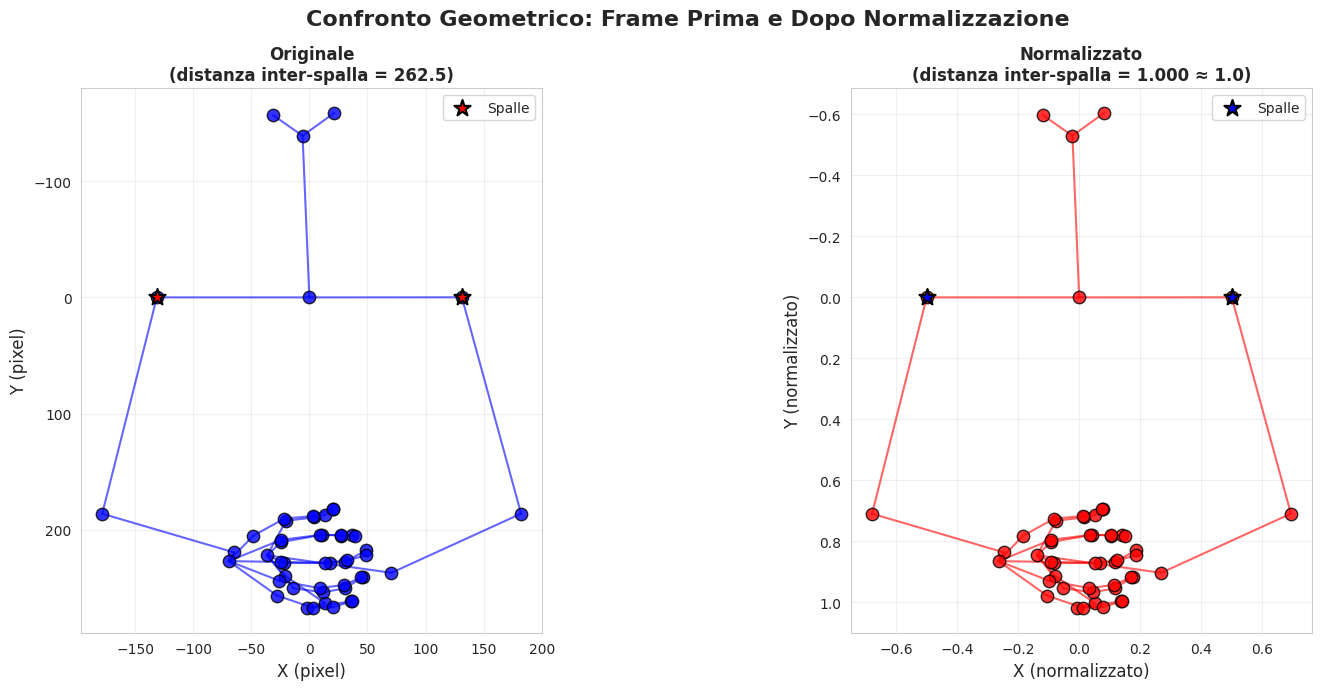


📏 CONFRONTO LUNGHEZZE OSSEE DEL FRAME:

RShoulder:
  Originale:    131.24 pixel
  Normalizzato: 0.5000
  Rapporto:     0.0038 (≈ 1/262.5)

RElbow:
  Originale:    192.01 pixel
  Normalizzato: 0.7315
  Rapporto:     0.0038 (≈ 1/262.5)

RWrist:
  Originale:    118.39 pixel
  Normalizzato: 0.4510
  Rapporto:     0.0038 (≈ 1/262.5)

LElbow:
  Originale:    193.01 pixel
  Normalizzato: 0.7353
  Rapporto:     0.0038 (≈ 1/262.5)

LWrist:
  Originale:    122.66 pixel
  Normalizzato: 0.4673
  Rapporto:     0.0038 (≈ 1/262.5)


In [24]:
# Carica un dataset di esempio e prendi un frame
sample_idx = np.random.choice(len(intervals))
clips = load_multiple_samples(speaker=speaker, interval_ids=intervals[sample_idx:sample_idx+1])

skeleton_poses = []
for clip in clips:
    pose = clip['pose']
    pose[:, 0] = [0.0, 0.0]  # centra il collo
    skeleton_poses.append(pose)

skeleton_poses = np.concatenate(skeleton_poses, axis=0)

# Prendi un frame a metà della sequenza
frame_idx = len(skeleton_poses) // 2
frame_orig = skeleton_poses[frame_idx]  # (J, 2)
frame_norm = SkeletonPATS.normalize_skeleton(frame_orig, scale=1.0)

# Calcola distanza inter-spalla
shoulder_dist_orig = np.linalg.norm(frame_orig[4] - frame_orig[1])
shoulder_dist_norm = np.linalg.norm(frame_norm[4] - frame_norm[1])

print(f"Frame selezionato: {frame_idx} del dataset {sample_idx}")
print(f"Distanza inter-spalla originale: {shoulder_dist_orig:.2f} pixel")
print(f"Distanza inter-spalla normalizzata: {shoulder_dist_norm:.2f} (target = 1.0)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Confronto Geometrico: Frame Prima e Dopo Normalizzazione', fontsize=16, fontweight='bold')

parents = SkeletonPATS.parents()
joint_names = SkeletonPATS.joint_names()

# Plot frame originale
ax = axes[0]
for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([frame_orig[j, 0], frame_orig[parent_idx, 0]],
               [frame_orig[j, 1], frame_orig[parent_idx, 1]],
               'b-', linewidth=1.5, alpha=0.6)

ax.scatter(frame_orig[:, 0], frame_orig[:, 1], c='blue', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

# Evidenzia spalle
ax.scatter([frame_orig[1, 0], frame_orig[4, 0]], 
          [frame_orig[1, 1], frame_orig[4, 1]], 
          c='red', s=150, marker='*', edgecolors='black', linewidth=1.5, 
          zorder=10, label='Spalle')

ax.set_xlabel('X (pixel)', fontsize=12)
ax.set_ylabel('Y (pixel)', fontsize=12)
ax.set_title(f'Originale\n(distanza inter-spalla = {shoulder_dist_orig:.1f})', fontweight='bold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()

# Plot frame normalizzato
ax = axes[1]
for j, parent_idx in enumerate(parents):
    if parent_idx >= 0:
        ax.plot([frame_norm[j, 0], frame_norm[parent_idx, 0]],
               [frame_norm[j, 1], frame_norm[parent_idx, 1]],
               'r-', linewidth=1.5, alpha=0.6)

ax.scatter(frame_norm[:, 0], frame_norm[:, 1], c='red', s=80, 
          edgecolors='black', linewidth=1, zorder=5, alpha=0.8)

# Evidenzia spalle
ax.scatter([frame_norm[1, 0], frame_norm[4, 0]], 
          [frame_norm[1, 1], frame_norm[4, 1]], 
          c='blue', s=150, marker='*', edgecolors='black', linewidth=1.5, 
          zorder=10, label='Spalle')

ax.set_xlabel('X (normalizzato)', fontsize=12)
ax.set_ylabel('Y (normalizzato)', fontsize=12)
ax.set_title(f'Normalizzato\n(distanza inter-spalla = {shoulder_dist_norm:.3f} ≈ 1.0)', fontweight='bold')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Calcola e mostra alcune lunghezze ossee specifiche
bones_to_check = [
    (1, 'RShoulder'),
    (2, 'RElbow'),
    (3, 'RWrist'),
    (5, 'LElbow'),
    (6, 'LWrist')
]

print("\n📏 CONFRONTO LUNGHEZZE OSSEE DEL FRAME:")
print("="*60)
bone_lengths_orig = SkeletonPATS.compute_bone_lengths(frame_orig)
bone_lengths_norm = SkeletonPATS.compute_bone_lengths(frame_norm)

for joint_idx, joint_name in bones_to_check:
    orig_len = bone_lengths_orig[joint_idx]
    norm_len = bone_lengths_norm[joint_idx]
    ratio = norm_len / orig_len if orig_len > 0 else 0
    
    print(f"\n{joint_name}:")
    print(f"  Originale:    {orig_len:.2f} pixel")
    print(f"  Normalizzato: {norm_len:.4f}")
    print(f"  Rapporto:     {ratio:.4f} (≈ 1/{shoulder_dist_orig:.1f})")

## 8. Test sul Clustering: Valutazione Quantitativa

Per valutare rigorosamente l'utilità della normalizzazione, confrontiamo la qualità del clustering su dati originali vs normalizzati. Un clustering di qualità superiore indica che la normalizzazione ha rimosso variabilità non informativa, facilitando la scoperta di pattern intrinseci.

### Metriche di Valutazione

- **Silhouette Score**: misura la coesione e separazione dei cluster ($-1$ a $+1$, valori più alti = meglio)
- **Numero di Cluster**: identificati automaticamente da HDBSCAN
- **Noise ratio**: percentuale di punti classificati come outlier

### Metodologia

Per ogni dataset:
1. Concateniamo tutti i frame in un unico spazio feature (flatten delle pose)
2. Applichiamo PCA per ridurre dimensionalità (mantenendo 95% varianza)
3. Eseguiamo HDBSCAN con parametri identici su originale e normalizzato
4. Confrontiamo le metriche di clustering

In [34]:
from sklearn.decomposition import PCA
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score
from tqdm import tqdm

def cluster_analysis(poses, normalized=False, scale=1.0, min_cluster_size=10):
    """
    Esegue clustering su un set di pose e restituisce metriche di qualità.
    
    Args:
        poses: Array di pose (T, J, 2)
        normalized: Se True, normalizza prima del clustering
        scale: Fattore di scala per normalizzazione
        min_cluster_size: Parametro min_cluster_size per HDBSCAN
        
    Returns:
        dict con metriche di clustering
    """
    # Normalizza se richiesto
    if normalized:
        poses = SkeletonPATS.normalize_skeleton(poses, scale=scale)
    
    # Flatten: (T, J, 2) -> (T, J*2)
    n_frames = poses.shape[0]
    X = poses.reshape(n_frames, -1)
    
    # PCA per riduzione dimensionalità
    pca = UMAP(n_components=2, random_state=42)
    X_reduced = pca.fit_transform(X)
    
    # HDBSCAN clustering
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=5,
        metric='euclidean',
        cluster_selection_method='leaf'
    )
    labels = clusterer.fit_predict(X_reduced)
    
    # Calcola metriche
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    # Silhouette score (solo se ci sono almeno 2 cluster e punti non-noise)
    if n_clusters >= 2 and n_noise < len(labels):
        # Escludi noise per silhouette
        mask = labels != -1
        if mask.sum() > 0:
            sil_score = silhouette_score(X_reduced[mask], labels[mask])
        else:
            sil_score = -1.0
    else:
        sil_score = -1.0
    
    # Persistence: misura la stabilità dei cluster (da cluster_persistence_)
    persistence = 0.0
    if hasattr(clusterer, 'cluster_persistence_') and len(clusterer.cluster_persistence_) > 0:
        persistence = np.mean(clusterer.cluster_persistence_)
    
    # Average membership probability: misura la confidenza delle assegnazioni
    avg_prob = 0.0
    if hasattr(clusterer, 'probabilities_') and len(clusterer.probabilities_) > 0:
        # Escludi punti noise (prob = 0)
        probs = clusterer.probabilities_[clusterer.probabilities_ > 0]
        if len(probs) > 0:
            avg_prob = np.mean(probs)
    
    return {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette_score': sil_score,
        'persistence': persistence,
        'avg_prob': avg_prob,
        'n_components_pca': X_reduced.shape[1],
    }

print("Funzione cluster_analysis definita.")

Funzione cluster_analysis definita.


In [35]:
# Esegui clustering su tutti i dataset
clustering_results = []

print("Inizio analisi di clustering sui dataset...")
print(f"Dataset da analizzare: {N_DATASETS}")
print("="*80)

for idx in tqdm(range(N_DATASETS), desc="Clustering analysis"):
    try:
        # Carica dataset
        clips = load_multiple_samples(
            speaker=speaker, 
            interval_ids=intervals[idx:idx+1]
        )
        
        # Estrai pose
        skeleton_poses = []
        for clip in clips:
            pose = clip['pose']
            pose[:, 0] = [0.0, 0.0]
            skeleton_poses.append(pose)
        
        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        
        # Salta dataset troppo piccoli
        if len(skeleton_poses) < 20:
            continue
        
        # Clustering su originale
        metrics_orig = cluster_analysis(
            skeleton_poses, 
            normalized=False,
            min_cluster_size=max(5, len(skeleton_poses) // 20)
        )
        
        # Clustering su normalizzato
        metrics_norm = cluster_analysis(
            skeleton_poses, 
            normalized=True,
            scale=1.0,
            min_cluster_size=max(5, len(skeleton_poses) // 20)
        )
        
        clustering_results.append({
            'dataset_idx': idx,
            'n_frames': len(skeleton_poses),
            # Metriche originale
            'orig_n_clusters': metrics_orig['n_clusters'],
            'orig_silhouette': metrics_orig['silhouette_score'],
            'orig_noise_ratio': metrics_orig['noise_ratio'],
            'orig_persistence': metrics_orig['persistence'],
            'orig_avg_prob': metrics_orig['avg_prob'],
            'orig_pca_components': metrics_orig['n_components_pca'],
            # Metriche normalizzato
            'norm_n_clusters': metrics_norm['n_clusters'],
            'norm_silhouette': metrics_norm['silhouette_score'],
            'norm_noise_ratio': metrics_norm['noise_ratio'],
            'norm_persistence': metrics_norm['persistence'],
            'norm_avg_prob': metrics_norm['avg_prob'],
            'norm_pca_components': metrics_norm['n_components_pca'],
        })
        
    except Exception as e:
        print(f"\nErrore nel dataset {idx}: {e}")
        continue

# Converti in DataFrame
df_clustering = pd.DataFrame(clustering_results)

print(df_clustering.head(10))

print(f"\n✅ Analisi completata su {len(df_clustering)} dataset")

Inizio analisi di clustering sui dataset...
Dataset da analizzare: 202


Clustering analysis: 100%|██████████| 202/202 [06:56<00:00,  2.06s/it]

   dataset_idx  n_frames  orig_n_clusters  orig_silhouette  orig_noise_ratio  \
0            0       735               11         0.650466          0.099320   
1            1       409               10         0.672028          0.063570   
2            2       123                6         0.828507          0.317073   
3            3       294                9         0.659783          0.071429   
4            4       567               11         0.688742          0.174603   
5            5       338                7         0.633742          0.106509   
6            6       239               12         0.686672          0.129707   
7            7       142                7         0.690282          0.169014   
8            8       789                8         0.589281          0.108999   
9            9       107                5         0.663501          0.177570   

   orig_persistence  orig_avg_prob  orig_pca_components  norm_n_clusters  \
0          0.324251       0.897654         

## 9. Confronto Statistico delle Metriche di Clustering

Analizziamo le differenze nelle metriche di clustering tra dati originali e normalizzati usando test statistici paired.

In [36]:
from scipy.stats import wilcoxon, ttest_rel

# Calcola differenze (delta)
df_clustering['delta_silhouette'] = df_clustering['norm_silhouette'] - df_clustering['orig_silhouette']
df_clustering['delta_noise_ratio'] = df_clustering['norm_noise_ratio'] - df_clustering['orig_noise_ratio']
df_clustering['delta_n_clusters'] = df_clustering['norm_n_clusters'] - df_clustering['orig_n_clusters']
df_clustering['delta_persistence'] = df_clustering['norm_persistence'] - df_clustering['orig_persistence']
df_clustering['delta_avg_prob'] = df_clustering['norm_avg_prob'] - df_clustering['orig_avg_prob']

print("="*80)
print("CONFRONTO STATISTICO: CLUSTERING ORIGINALE vs NORMALIZZATO")
print("="*80)

# 1. Silhouette Score
print("\n📊 SILHOUETTE SCORE (valori più alti = meglio)")
print("-"*80)
valid_sil = df_clustering[
    (df_clustering['orig_silhouette'] > -1) & 
    (df_clustering['norm_silhouette'] > -1)
]

if len(valid_sil) > 0:
    print(f"Dataset validi per analisi: {len(valid_sil)}")
    print(f"\nOriginale:    μ={valid_sil['orig_silhouette'].mean():.4f}, σ={valid_sil['orig_silhouette'].std():.4f}")
    print(f"Normalizzato: μ={valid_sil['norm_silhouette'].mean():.4f}, σ={valid_sil['norm_silhouette'].std():.4f}")
    print(f"Δ medio:      {valid_sil['delta_silhouette'].mean():.4f}")
    
    improved = (valid_sil['delta_silhouette'] > 0).sum()
    worsened = (valid_sil['delta_silhouette'] < 0).sum()
    unchanged = (valid_sil['delta_silhouette'] == 0).sum()
    
    print(f"\nDataset migliorati:  {improved} ({improved/len(valid_sil)*100:.1f}%)")
    print(f"Dataset peggiorati:  {worsened} ({worsened/len(valid_sil)*100:.1f}%)")
    print(f"Dataset invariati:   {unchanged} ({unchanged/len(valid_sil)*100:.1f}%)")
    
    # Test statistici
    if len(valid_sil) >= 3:
        w_stat, w_p = wilcoxon(valid_sil['delta_silhouette'])
        print(f"\nWilcoxon signed-rank test:")
        print(f"  Statistica: {w_stat:.2f}")
        print(f"  p-value: {w_p:.4e}")
        print(f"  Significativo? {'✓ Sì (p < 0.05)' if w_p < 0.05 else '✗ No'}")

# 2. Noise Ratio
print("\n\n📊 NOISE RATIO (valori più bassi = meglio)")
print("-"*80)
print(f"Originale:    μ={df_clustering['orig_noise_ratio'].mean():.4f}, σ={df_clustering['orig_noise_ratio'].std():.4f}")
print(f"Normalizzato: μ={df_clustering['norm_noise_ratio'].mean():.4f}, σ={df_clustering['norm_noise_ratio'].std():.4f}")
print(f"Δ medio:      {df_clustering['delta_noise_ratio'].mean():.4f}")

improved_noise = (df_clustering['delta_noise_ratio'] < 0).sum()
print(f"\nDataset con meno noise dopo normalizzazione: {improved_noise} ({improved_noise/len(df_clustering)*100:.1f}%)")

if len(df_clustering) >= 3:
    w_stat, w_p = wilcoxon(df_clustering['delta_noise_ratio'])
    print(f"\nWilcoxon signed-rank test:")
    print(f"  Statistica: {w_stat:.2f}")
    print(f"  p-value: {w_p:.4e}")
    print(f"  Significativo? {'✓ Sì (p < 0.05)' if w_p < 0.05 else '✗ No'}")

# 3. Numero di Cluster
print("\n\n📊 NUMERO DI CLUSTER")
print("-"*80)
print(f"Originale:    μ={df_clustering['orig_n_clusters'].mean():.2f}, σ={df_clustering['orig_n_clusters'].std():.2f}")
print(f"Normalizzato: μ={df_clustering['norm_n_clusters'].mean():.2f}, σ={df_clustering['norm_n_clusters'].std():.2f}")
print(f"Δ medio:      {df_clustering['delta_n_clusters'].mean():.2f}")

# 4. Persistence (valori più alti = cluster più stabili)
print("\n\n📊 PERSISTENCE (valori più alti = meglio)")
print("-"*80)
if df_clustering['orig_persistence'].sum() > 0:  # Check se i dati sono disponibili
    print(f"Originale:    μ={df_clustering['orig_persistence'].mean():.4f}, σ={df_clustering['orig_persistence'].std():.4f}")
    print(f"Normalizzato: μ={df_clustering['norm_persistence'].mean():.4f}, σ={df_clustering['norm_persistence'].std():.4f}")
    print(f"Δ medio:      {df_clustering['delta_persistence'].mean():.4f}")
    
    improved_pers = (df_clustering['delta_persistence'] > 0).sum()
    print(f"\nDataset con persistence migliorata: {improved_pers} ({improved_pers/len(df_clustering)*100:.1f}%)")
    
    if len(df_clustering) >= 3:
        w_stat, w_p = wilcoxon(df_clustering['delta_persistence'])
        print(f"\nWilcoxon signed-rank test:")
        print(f"  Statistica: {w_stat:.2f}")
        print(f"  p-value: {w_p:.4e}")
        print(f"  Significativo? {'✓ Sì (p < 0.05)' if w_p < 0.05 else '✗ No'}")
else:
    print("⚠️  Dati persistence non disponibili")

# 5. Average Membership Probability (valori più alti = assegnazioni più sicure)
print("\n\n📊 AVERAGE MEMBERSHIP PROBABILITY (valori più alti = meglio)")
print("-"*80)
if df_clustering['orig_avg_prob'].sum() > 0:  # Check se i dati sono disponibili
    print(f"Originale:    μ={df_clustering['orig_avg_prob'].mean():.4f}, σ={df_clustering['orig_avg_prob'].std():.4f}")
    print(f"Normalizzato: μ={df_clustering['norm_avg_prob'].mean():.4f}, σ={df_clustering['norm_avg_prob'].std():.4f}")
    print(f"Δ medio:      {df_clustering['delta_avg_prob'].mean():.4f}")
    
    improved_prob = (df_clustering['delta_avg_prob'] > 0).sum()
    print(f"\nDataset con probabilità media migliorata: {improved_prob} ({improved_prob/len(df_clustering)*100:.1f}%)")
    
    if len(df_clustering) >= 3:
        w_stat, w_p = wilcoxon(df_clustering['delta_avg_prob'])
        print(f"\nWilcoxon signed-rank test:")
        print(f"  Statistica: {w_stat:.2f}")
        print(f"  p-value: {w_p:.4e}")
        print(f"  Significativo? {'✓ Sì (p < 0.05)' if w_p < 0.05 else '✗ No'}")
else:
    print("⚠️  Dati avg_prob non disponibili")

# Summary finale
print("\n\n" + "="*80)
print("SINTESI RISULTATI")
print("="*80)

sil_improvement = valid_sil['delta_silhouette'].mean() if len(valid_sil) > 0 else 0
noise_improvement = -df_clustering['delta_noise_ratio'].mean()  # negativo perché vogliamo riduzione

if sil_improvement > 0:
    print(f"✅ Silhouette score: MIGLIORATO in media di {sil_improvement:.4f}")
else:
    print(f"⚠️  Silhouette score: Peggiorato di {abs(sil_improvement):.4f}")

if noise_improvement > 0:
    print(f"✅ Noise ratio: RIDOTTO in media di {noise_improvement:.4f}")
else:
    print(f"⚠️  Noise ratio: Aumentato di {abs(noise_improvement):.4f}")

print("="*80)

CONFRONTO STATISTICO: CLUSTERING ORIGINALE vs NORMALIZZATO

📊 SILHOUETTE SCORE (valori più alti = meglio)
--------------------------------------------------------------------------------
Dataset validi per analisi: 202

Originale:    μ=0.6713, σ=0.0618
Normalizzato: μ=0.6713, σ=0.0605
Δ medio:      0.0000

Dataset migliorati:  102 (50.5%)
Dataset peggiorati:  100 (49.5%)
Dataset invariati:   0 (0.0%)

Wilcoxon signed-rank test:
  Statistica: 10127.00
  p-value: 8.8103e-01
  Significativo? ✗ No


📊 NOISE RATIO (valori più bassi = meglio)
--------------------------------------------------------------------------------
Originale:    μ=0.1722, σ=0.1092
Normalizzato: μ=0.1216, σ=0.0735
Δ medio:      -0.0506

Dataset con meno noise dopo normalizzazione: 126 (62.4%)

Wilcoxon signed-rank test:
  Statistica: 5194.50
  p-value: 5.2060e-08
  Significativo? ✓ Sì (p < 0.05)


📊 NUMERO DI CLUSTER
--------------------------------------------------------------------------------
Originale:    μ=7.54, 